In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data loading
transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(root="../data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="../data", train=False, download=True, transform=transform)

val_size = 10000
train_size = len(train_full) - val_size

train_data, val_data = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Data loaded successfully.")

Using device: cpu
Data loaded successfully.


In [2]:
torch.manual_seed(42) # For reproducibility

# Improved Model: more hidden units (128 instead of 64)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),  # Increased from 64 to 128
    nn.ReLU(),
    nn.Linear(128, 10)    # Must match the 128 above
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
epochs = 15 # Changed from 3 to 15

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            running_val += loss.item() * images.size(0)

    val_loss = running_val / len(val_loader.dataset)
    val_losses.append(val_loss)

    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

Epoch 3: train_loss=0.3739, val_loss=0.3653
Epoch 6: train_loss=0.3051, val_loss=0.3305
Epoch 9: train_loss=0.2706, val_loss=0.3240
Epoch 12: train_loss=0.2430, val_loss=0.3186
Epoch 15: train_loss=0.2214, val_loss=0.3149


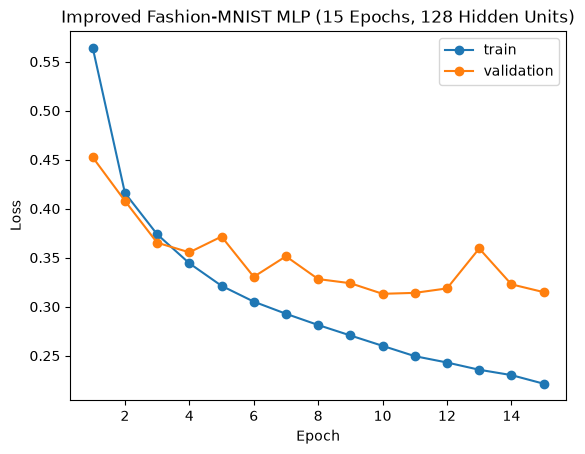

In [3]:
os.makedirs("../reports", exist_ok=True)
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, epochs + 1), val_losses, marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Fashion-MNIST MLP (15 Epochs, 128 Hidden Units)")
plt.legend()
plt.savefig("../reports/loss_curve_improved.png", dpi=200)
plt.show()

In [4]:
correct = []
incorrect = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        for img, label, pred, prob in zip(images, labels, preds, probs):
            if pred.item() == label.item():
                if len(correct) < 5:
                    correct.append((img.cpu(), label.item(), pred.item(), prob.max().item()))
            else:
                if len(incorrect) < 5:
                    incorrect.append((img.cpu(), label.item(), pred.item(), prob.max().item()))

            if len(correct) == 5 and len(incorrect) == 5:
                break
        if len(correct) == 5 and len(incorrect) == 5:
            break
print("Predictions collected.")

Predictions collected.


Correct predictions:


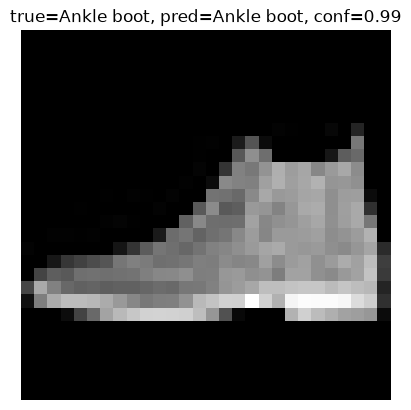

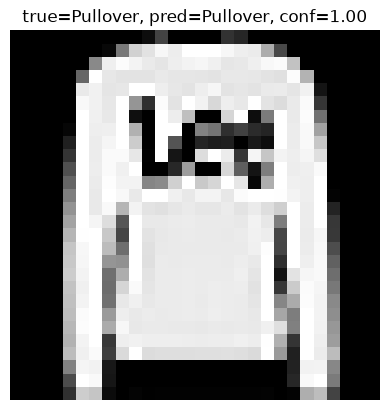

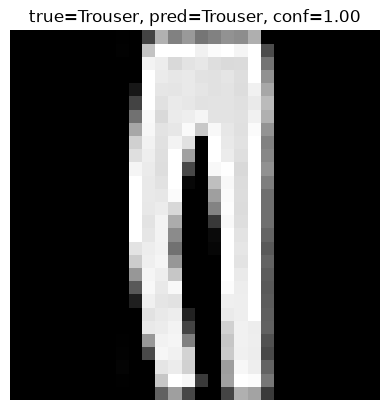

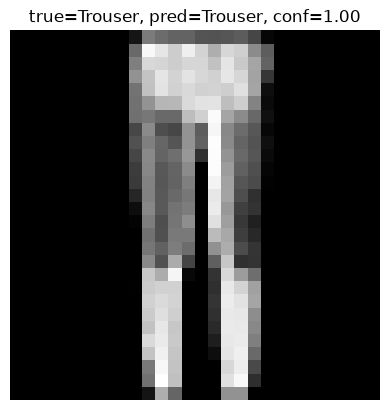

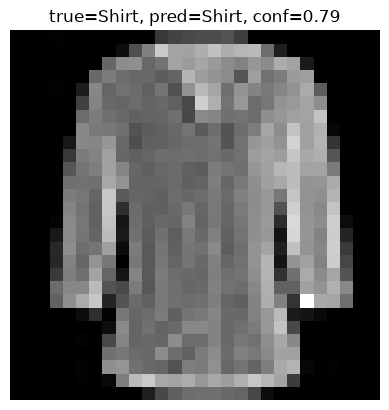

Incorrect predictions:


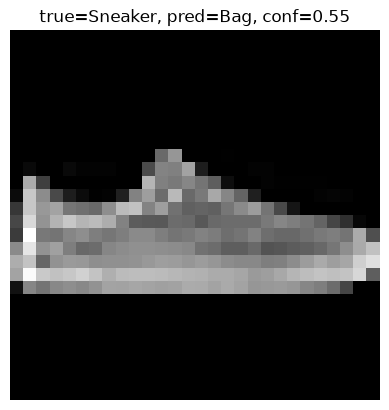

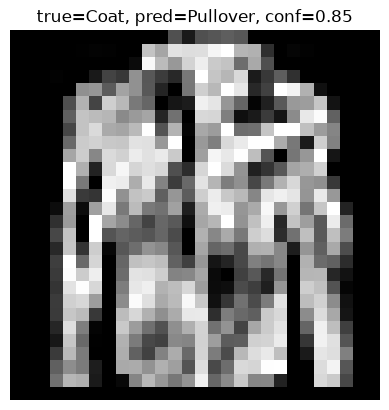

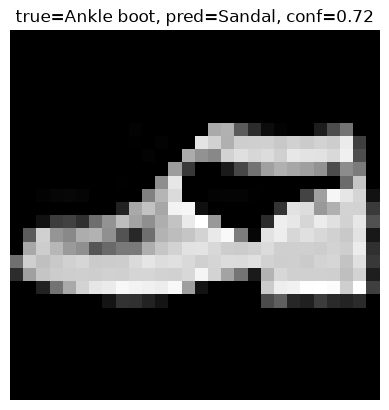

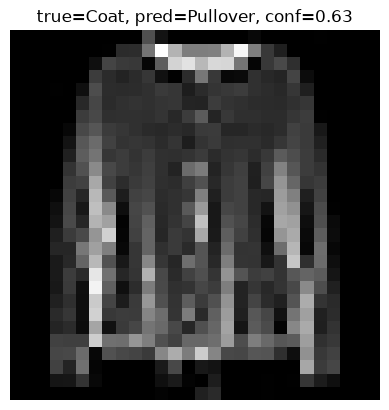

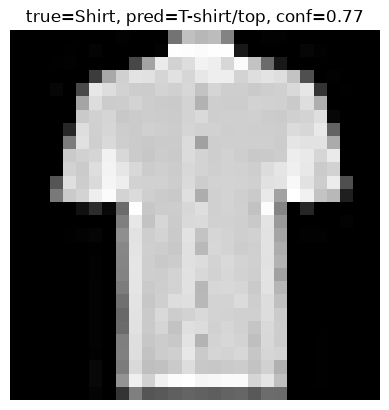

In [5]:
def show_prediction(item):
    img, true, pred, conf = item
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"true={class_names[true]}, pred={class_names[pred]}, conf={conf:.2f}")
    plt.axis("off")
    plt.show()

print("Correct predictions:")
for item in correct:
    show_prediction(item)

print("Incorrect predictions:")
for item in incorrect:
    show_prediction(item)

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# 1. The Preprocessing Pipeline
custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Convert to black & white
    transforms.Resize((28, 28)),                 # Shrink to 28x28 pixels
    transforms.ToTensor()                        # Convert to a PyTorch tensor
])

# 2. The Prediction Function
def predict_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert("RGB")
    
    # Preprocess the image
    img_tensor = custom_transform(img)
    
    # Add batch dimension: [1, 28, 28] -> [1, 1, 28, 28]
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs.max().item()
        
    # Display the result
    plt.imshow(img, cmap="gray")
    plt.title(f"Predicted: {class_names[pred_idx]} | Confidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

print("Prediction function ready!")

Prediction function ready!


--- Regular Shoe ---


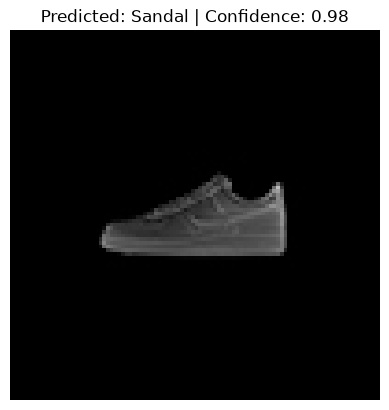


--- Bag ---


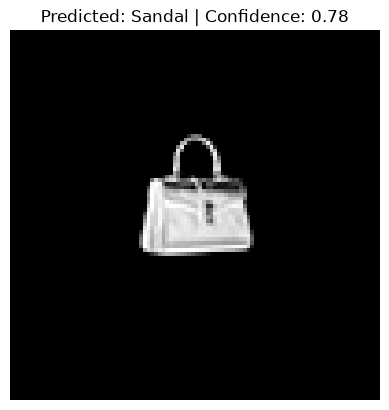


--- Inverted Shoe ---


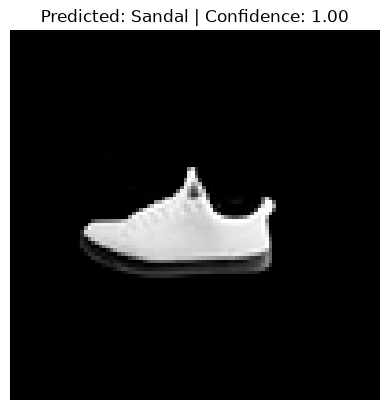

In [7]:
# Test the regular shoe image
print("--- Regular Shoe ---")
predict_custom_image("shoe.jpg")

# Test the bag image
print("\n--- Bag ---")
predict_custom_image("bag.jpg")

# Test your inverted black/white shoe
print("\n--- Inverted Shoe ---")
predict_custom_image("test_shoe.jpg")

## Reflection

The first thing that failed was the shape mismatch during the debugging challenge. I deliberately set a linear layer to `nn.Linear(3, 1)` instead of `8, 1`. The evidence that helped me fix it was reading the traceback: `mat1 and mat2 shapes cannot be multiplied (4x8 and 3x1)`. By reasoning about the dimensions, I realized the hidden layer output 8 features, so the next layer needed to accept 8 inputs.

If I were to test next, I would replace the MLP with a Convolutional Neural Network (CNN). My real-world inference test showed that the MLP predicted "Sandal" for every custom image because it lacks spatial awareness and cannot handle domain shifts (different backgrounds, lighting). A CNN would preserve the spatial structure of the image and be much more robust for real-world classification.